# DMAIC · Dock-to-stock do CD-AM1 (Manaus)

Projeto Black Belt no caso Vértice. O CD-AM1 entrou em operação em ago/2025 para viabilizar a promessa de prazo no Norte, mas a mercadoria recebida demora a ficar disponível para venda. No painel, ele é o único CD **não capaz nem no curto prazo** (Cpk < 1 contra o SLA de 12 h).

> **Como ler.** Cada fase termina com **🎯 Tollgate**, o que o patrocinador precisa aprovar para seguir. As caixas **🧠 Por dentro** explicam a estatística e o Python. Dados fictícios (`kpikit.dmaic`), com causas plantadas como premissas. O objetivo é demonstrar o método.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from kpikit import dmaic, spc, kpis, simulador
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
d = simulador.carregar()
rec = d['fato_recebimentos_am1']
base = rec[rec.fase == 'medir']
rec.groupby('fase').agg(recebimentos=('recebimento_id', 'size'), inicio=('chegada', 'min'), fim=('chegada', 'max'))

,recebimentos,inicio,fim
fase,,,
controle,1286,2026-07-27 06:00:00.000000000,2026-09-26 17:51:32.246923971
medir,1154,2026-02-02 07:21:53.055655747,2026-03-28 20:27:02.378972242
piloto,1122,2026-06-01 06:19:22.211266839,2026-07-25 19:52:31.970684611


## D · Definir

**Project charter**

| Campo | Conteúdo |
|---|---|
| **Problema** | No 1T26, 5% dos recebimentos do CD-AM1 ficaram disponíveis para venda **depois de 12 h** (SLA com o Comercial), e o P90 foi de ~9,6 h. Mercadoria parada na doca vira ruptura no site, num CD que existe para encurtar prazo no Norte. |
| **Meta** | P90 ≤ 6 h e Ppk ≥ 1,0 contra o SLA de 12 h até set/2026, sem aumentar o custo por recebimento |
| **Escopo** | Da chegada do veículo à portaria até o endereçamento confirmado no WMS. Fora: devoluções e transferências entre CDs |
| **Métrica primária (Y)** | Dock-to-stock por recebimento (h) |
| **Métricas secundárias** | Divergência de recebimento (%), produtividade de conferência |
| **Contrapeso** | Acurácia de inventário (SC-005) não pode cair: velocidade sem conferência é só esconder o erro |
| **Negócio** | O2 (expansão nacional) e O3 (tecnologia); KR3.2 dock-to-stock |
| **Time** | Black Belt (líder) · gerente do CD-AM1 (dono do processo) · Compras · TI/WMS · 2 conferentes · patrocinador: Diretoria de Supply Chain |

**SIPOC**

| Fornecedores | Entradas | Processo | Saídas | Clientes |
|---|---|---|---|---|
| Fornecedores de mercadoria, transportadoras, Compras | NF-e/XML, ASN, agendamento, carga | 1. Portaria e fila → 2. Descarga → 3. Conferência → 4. Tratativa de divergência → 5. Armazenagem | Estoque disponível no WMS, divergências registradas | Comercial (site), planejamento, cliente final |

**VOC → CTQ:** "o produto aparece como disponível no site no mesmo dia em que chegou" → **CTQ: dock-to-stock ≤ 12 h em ≥ 99% dos recebimentos**.

## M · Medir

🧠 **Antes de medir, valide o sistema de medição (MSA).** Aqui a métrica vem de *timestamps*: portaria, WMS e coletor. Três checagens que evitam um projeto inteiro em cima de um dado errado:
1. **Relógios sincronizados** entre portaria, WMS e coletores (uma diferença de fuso ou relógio atrasado cria "tempos negativos").
2. **Definição operacional única** do evento final: *endereçamento confirmado*, não "mercadoria guardada".
3. **Concordância de atributo** para "divergência": dois conferentes classificam a mesma NF da mesma forma? (Kappa ≥ 0,7.)

,linha de base
n,"1,154.000"
mediana,5.055
p90,9.604
pct_fora_sla,0.051
ppm_fora_sla,"51,126.516"
ppk_percentil,0.441
ppk_normal_enganoso,0.679


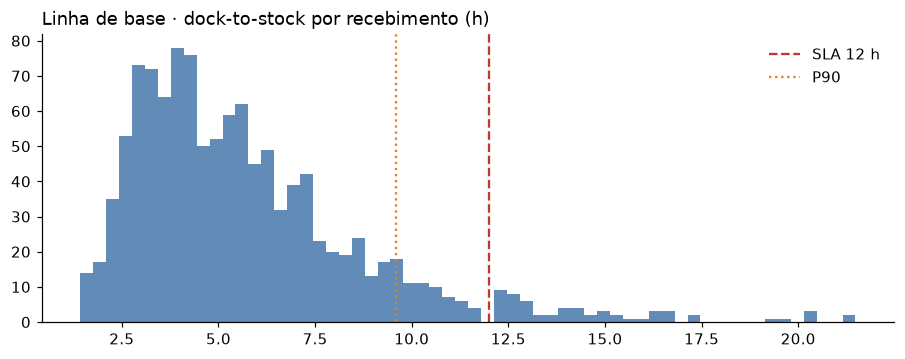

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(base.dock_to_stock_h, bins=60, color='#3b6ea5', alpha=.8)
ax.axvline(dmaic.LSE_HORAS, color='#c0392b', ls='--', label='SLA 12 h')
ax.axvline(base.dock_to_stock_h.quantile(.9), color='#e67e22', ls=':', label='P90')
ax.set_title('Linha de base · dock-to-stock por recebimento (h)', loc='left'); ax.legend(frameon=False)
pd.Series(dmaic.capabilidade_nao_normal(base.dock_to_stock_h)).to_frame('linha de base')

🧠 **Por dentro da técnica · capability de dados não normais.** Tempo de processo tem **cauda longa à direita**: não existe tempo negativo, mas existe a carga que trava 20 h. O Ppk clássico supõe distribuição normal e usa média ± 3σ. Numa cauda longa, **ele superestima a capacidade** (aqui, 0,68 contra 0,44). O método dos percentis (ISO 22514-2) troca o "3σ" pela distância real entre a mediana e o percentil 99,865 dos dados:

$$P_{pk} = \frac{LSE - \text{mediana}}{P_{99,865} - \text{mediana}}$$

🎯 **Tollgate M:** linha de base de **~51 mil PPM** fora do SLA, P90 de 9,6 h e Ppk (percentis) de 0,44. O processo **não é capaz**, e o dado é confiável.

## A · Analisar

In [3]:
print('TODAS AS CARGAS'); display(dmaic.pareto(base))
print('SÓ CARGAS ACIMA DO SLA DE 12 h'); display(dmaic.pareto(base, so_cauda=True))

TODAS AS CARGAS


,horas,pct,pct_acumulado
espera_doca_h,"2,416.000",0.365,0.365
descarga_h,"1,345.000",0.203,0.568
conferencia_h,"1,115.000",0.168,0.736
armazenagem_h,928.000,0.140,0.876
tratativa_divergencia_h,820.000,0.124,1.000


SÓ CARGAS ACIMA DO SLA DE 12 h


,horas,pct,pct_acumulado
tratativa_divergencia_h,398.000,0.459,0.459
espera_doca_h,273.000,0.314,0.773
descarga_h,86.000,0.099,0.872
conferencia_h,60.000,0.070,0.942
armazenagem_h,51.000,0.058,1.000


🎯 **O achado central do projeto.** O Pareto das **horas totais** aponta a *espera na doca* (36%). O Pareto só das **cargas que violam o SLA** aponta a *tratativa de divergência* (46%). **A média e a cauda têm causas diferentes.** Um projeto guiado só pela média atacaria a fila e continuaria violando o SLA. Um MBB sempre pergunta: *qual Pareto responde à pergunta do cliente?*

In [4]:
testes = {}
for fator in ['agendado', 'asn_antecipado', 'divergencia', 'tipo_carga', 'turno_chegada']:
    r = dmaic.comparar_grupos(base, fator)
    p = r.get('mann_whitney_p', r.get('kruskal_p'))
    testes[fator] = {'teste': 'Mann-Whitney' if 'mann_whitney_p' in r else 'Kruskal-Wallis', 'p_valor': p,
                     'conclusão': 'afeta o Y' if p < 0.05 else 'sem evidência'}
pd.DataFrame(testes).T

,teste,p_valor,conclusão
agendado,Mann-Whitney,0.000,afeta o Y
asn_antecipado,Mann-Whitney,0.000,afeta o Y
divergencia,Mann-Whitney,0.000,afeta o Y
tipo_carga,Kruskal-Wallis,0.000,afeta o Y
turno_chegada,Kruskal-Wallis,0.086,sem evidência


🧠 **Por dentro da técnica · teste de hipótese.**
- **H₀ (hipótese nula):** o fator *não* muda o dock-to-stock. O **p-valor** é a probabilidade de ver uma diferença igual ou maior que a observada *se H₀ fosse verdade*. p < 0,05 → rejeitamos H₀.
- **Por que Mann-Whitney e Kruskal-Wallis, e não o teste t?** São testes *não paramétricos*: comparam postos (rankings) em vez de médias e não exigem normalidade. Com cauda longa, são a escolha segura. O código também calcula o t de Welch e a ANOVA para comparação.
- **Turno de chegada: sem evidência.** Também é resultado. Descartar uma causa "óbvia" com dados poupa uma solução cara. Atenção, porém: só 3 cargas chegaram à noite. Ausência de evidência com amostra pequena **não é evidência de ausência**.

In [5]:
dmaic.comparar_grupos(base, 'agendado')['resumo']

,n,media,mediana,p90
agendado,,,,
False,700,6.790,6.100,10.670
True,454,4.120,3.500,6.830


In [6]:
q = dmaic.qui_quadrado(base, 'fornecedor')
print(f"Divergência por fornecedor · χ² = {q['qui2']:.1f}, gl = {q['gl']}, p = {q['p_valor']:.1e}")
q['taxa'].sort_values(ascending=False).head(5).to_frame('taxa_divergencia')

Divergência por fornecedor · χ² = 56.2, gl = 11, p = 4.7e-08


,taxa_divergencia
fornecedor,
F07,0.362
F03,0.322
F11,0.196
F08,0.145
F01,0.138


🧠 **Qui-quadrado de independência.** Divergência é sim ou não (atributo), não um tempo. O teste compara a tabela observada (fornecedor × divergência) com o que se esperaria se a taxa fosse igual para todos. **F03 e F07** divergem 2 a 3 vezes mais que os demais: é caso de desenvolvimento de fornecedor, não de conferência.

In [7]:
reg = dmaic.regressao_log(base)
print(f"R² = {reg.attrs['r2']:.2f}")
reg[['efeito_pct', 'p_valor']]

R² = 0.60


,efeito_pct,p_valor
intercepto,1.370,0.000
nao_agendado,0.711,0.000
sem_asn,0.101,0.000
divergencia,0.810,0.000
carga_batida,0.329,0.000
carga_mista,0.141,0.000
turno_noite,-0.199,0.217
skus_10,0.049,0.000


🧠 **Por dentro do código · regressão no log.** Modelar `log(tempo)` faz cada coeficiente virar um **efeito multiplicativo**: `e^β − 1` é o aumento percentual. Assim, "não agendado" aumenta o dock-to-stock em ~70% e "divergência" em ~80%, com todo o resto constante. Isso separa efeitos que andam juntos (fornecedor crítico → carga batida *e* divergência). O R² de ~0,60 diz que esses fatores explicam 60% da variação; o resto é ruído comum do processo.

**Causa raiz da divergência (5 porquês, resumo):** a NF trava inteira → a regra do WMS bloqueia a NF com qualquer item divergente → a regra foi desenhada para evitar entrada de item não pedido → ninguém revisou quando o volume cresceu → **não havia dono do processo de recebimento no CD novo.**

🎯 **Tollgate A:** causas raiz validadas estatisticamente: (1) recebimento sem agendamento, (2) NF inteira travada por divergência, (3) ausência de ASN, (4) carga batida dos fornecedores críticos.

## I · Melhorar

| Causa raiz | Solução | Impacto | Esforço | Dono |
|---|---|:-:|:-:|---|
| NF travada por divergência | **Recebimento parcial**: libera o conforme, segrega o divergente | Alto (cauda) | Baixo (regra WMS) | TI + Compras |
| Chegada sem agendamento | **Agendamento obrigatório** por janela no portal do fornecedor | Alto (média) | Médio | Compras |
| Sem ASN | **ASN/XML antecipado + conferência cega por scanner** | Médio | Médio | TI |
| Carga batida F03/F07 | **Desenvolvimento de fornecedor**: paletização padrão | Médio | Médio | Compras |

Piloto de 8 semanas (jun–jul/2026).

In [8]:
ad = dmaic.antes_depois(rec)
pd.Series(ad).to_frame('medir → piloto')

,medir → piloto
mediana_antes,5.055
mediana_depois,3.080
p90_antes,9.604
p90_depois,4.939
reducao_p90,0.486
mann_whitney_p,0.000
levene_p,0.000


,medir,piloto
n,"1,154.000","1,122.000"
mediana,5.055,3.080
p90,9.604,4.939
pct_fora_sla,0.051,0.001
ppm_fora_sla,"51,126.516",891.266
ppk_percentil,0.441,1.181
ppk_normal_enganoso,0.679,2.030


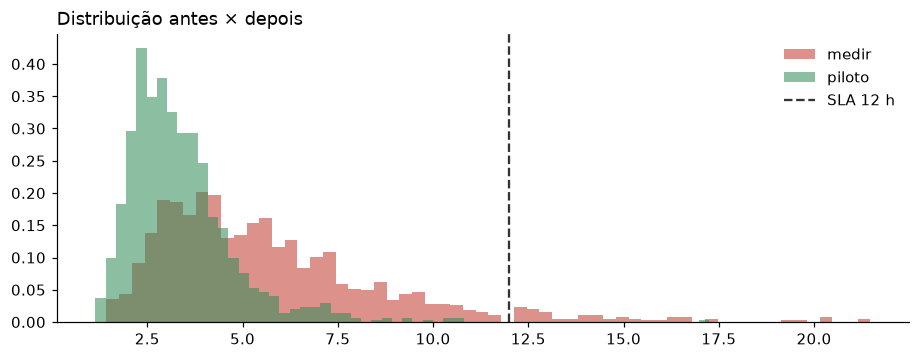

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.4))
for fase, cor in [('medir', '#c0392b'), ('piloto', '#2e8b57')]:
    ax.hist(rec.loc[rec.fase == fase, 'dock_to_stock_h'], bins=60, alpha=.55, color=cor, label=fase, density=True)
ax.axvline(dmaic.LSE_HORAS, color='#333', ls='--', label='SLA 12 h')
ax.set_title('Distribuição antes × depois', loc='left'); ax.legend(frameon=False)
pd.DataFrame({f: dmaic.capabilidade_nao_normal(rec.loc[rec.fase == f, 'dock_to_stock_h']) for f in ['medir', 'piloto']})

🧠 **Dois testes, duas perguntas.** O **Mann-Whitney** (unilateral) pergunta se o tempo *caiu*. O **Levene** pergunta se a *variação* mudou. A cauda encolheu, e é a cauda que viola o SLA.

🎯 **Tollgate I:** P90 caiu ~49% (9,6 h → 4,9 h), a fração fora do SLA foi de ~5% para ~0,1%, e o Ppk (percentis) passou de 0,44 para ~1,18. **Meta atingida no piloto.**

## C · Controlar

Controle: 54 dias · 0 fora dos limites do piloto


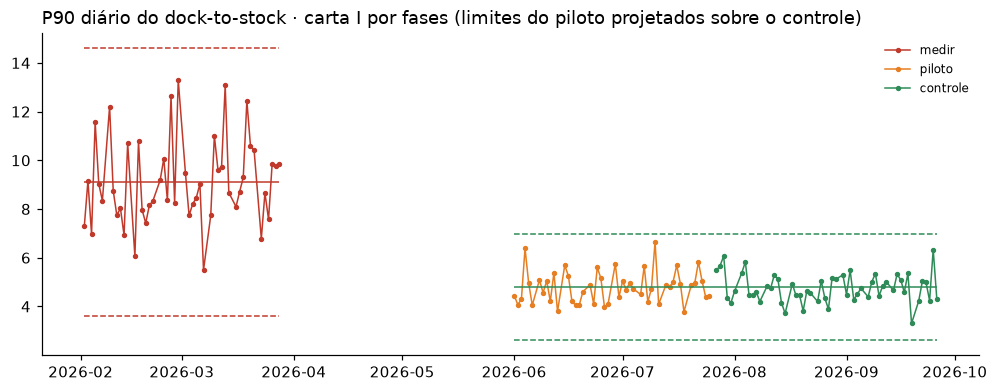

In [10]:
serie = dmaic.serie_diaria_p90(rec)
fig, ax = plt.subplots(figsize=(11, 3.8))
for fase, cor in [('medir', '#c0392b'), ('piloto', '#e67e22'), ('controle', '#2e8b57')]:
    s = serie[serie.fase == fase]
    ax.plot(s.index, s.p90, marker='o', ms=2.5, lw=1, color=cor, label=fase)
lim = spc.carta_imr(serie[serie.fase == 'piloto'].p90)
for col in ['centro', 'lsc', 'lic']:
    ax.hlines(lim[col].iloc[0], serie[serie.fase != 'medir'].index.min(), serie.index.max(), colors='#2e8b57',
              linestyles='-' if col == 'centro' else '--', lw=1)
base_lim = spc.carta_imr(serie[serie.fase == 'medir'].p90)
for col in ['centro', 'lsc', 'lic']:
    ax.hlines(base_lim[col].iloc[0], serie.index.min(), serie[serie.fase == 'medir'].index.max(), colors='#c0392b',
              linestyles='-' if col == 'centro' else '--', lw=1)
ax.set_title('P90 diário do dock-to-stock · carta I por fases (limites do piloto projetados sobre o controle)', loc='left')
ax.legend(frameon=False, fontsize=8)
ctl = serie[serie.fase == 'controle'].p90
fora = ((ctl > lim.lsc.iloc[0]) | (ctl < lim.lic.iloc[0])).sum()
print(f"Controle: {len(ctl)} dias · {fora} fora dos limites do piloto")

🧠 **Por dentro da técnica · carta por fases.** Depois de uma melhoria, os limites antigos não servem mais: o processo mudou de patamar. Calculamos **novos limites com os dados do piloto** e **congelamos** esses limites para monitorar a fase de controle. Pontos fora deles na fase de controle indicariam perda do ganho, que é o risco nº 1 de todo projeto Six Sigma (ver KPI LS-102, taxa de sustentação).

**Plano de controle**

| O quê | Como | Frequência | Limite de reação | Resposta | Dono |
|---|---|---|---|---|---|
| P90 diário do dock-to-stock | Carta I (limites do piloto) | Diária, Tier 2 | Ponto fora do LSC ou 7 pontos acima da média | Análise de causa em 24 h | Gerente CD-AM1 |
| % recebimentos agendados | Relatório do portal | Semanal | < 90% | Escalar para Compras / fornecedor | Compras |
| % com ASN antecipado | WMS | Semanal | < 80% | Bloqueio de agendamento sem ASN | TI |
| Divergência F03/F07 | Qui-quadrado mensal vs. demais | Mensal | Diferença significativa | Reunião de desenvolvimento de fornecedor | Compras |
| Contrapeso: acurácia de inventário | Inventário rotativo | Mensal | < 99,5% | Auditoria do recebimento parcial | Controle de estoque |

In [11]:
kpis.calcular(d, 'SC-006', freq='QS', por='unidade_id').unstack()[['CD-AM1']].dropna().T.round(2)

data,2025-07-01,2025-10-01,2026-01-01,2026-04-01,2026-07-01
unidade_id,,,,,
CD-AM1,9.360,11.190,8.740,7.630,5.000


In [12]:
horas_poupadas = (base.dock_to_stock_h.mean() - rec.loc[rec.fase == 'controle', 'dock_to_stock_h'].mean())
recebimentos_ano = len(rec[rec.fase == 'controle']) / 9 * 52
valor_medio_nf, margem, prob_venda_perdida_por_dia = 85_000, 0.22, 0.03   # premissas D — validar com Controladoria
beneficio = recebimentos_ano * horas_poupadas / 24 * valor_medio_nf * prob_venda_perdida_por_dia * margem
print(f"Horas de estoque indisponível evitadas por recebimento: {horas_poupadas:.1f} h · recebimentos/ano: {recebimentos_ano:,.0f}")
print(f"Benefício estimado (margem de vendas não perdidas): R$ {beneficio/1e6:,.2f} mi/ano  ⚠️ premissas a validar")

Horas de estoque indisponível evitadas por recebimento: 2.4 h · recebimentos/ano: 7,430
Benefício estimado (margem de vendas não perdidas): R$ 0.42 mi/ano  ⚠️ premissas a validar


🎯 **Tollgate C · encerramento.**
- O ganho se sustenta na fase de controle, com os limites do piloto. O **dono do processo** (gerente do CD-AM1) assume o plano de controle; o Black Belt sai.
- O resultado aparece no **KPI SC-006** do painel da rede: o dock-to-stock trimestral do CD-AM1 cai após jun/2026.
- **Benefício financeiro:** estimado por premissas explícitas e **validado pela Controladoria antes de entrar no LS-101 (hard savings)**. Soft savings não se somam a hard savings.
- **Replicação (Yokoten):** as soluções 1 e 3 são regras de WMS e portal, replicáveis nos outros CDs com custo marginal baixo. Esse é o próximo projeto do portfólio.

---
*Material de portfólio. Empresa, dados e causas são fictícios; o método é o de um projeto DMAIC real.*